Sois los ingenieros de datos de una consultora. Estáis evaluando tres modelos de lenguaje locales (Llama, Mistral y Gemma) para implementarlos en un servidor de inferencia. Necesitáis analizar su consumo de recursos y rendimiento utilizando Seaborn.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [7]:
datos_ia = {
    "Modelo": ["Llama-3"]*100 + ["Mistral"]*100 + ["Gemma"]*100,
    "Tiempo_Inferencia_ms": np.concatenate([
        np.random.normal(120, 15, 100),  # Llama (Consistente)
        np.concatenate([np.random.normal(90, 5, 50), np.random.normal(150, 5, 50)]), # Mistral (Bimodal)
        np.random.normal(100, 25, 100)   # Gemma (Muy disperso)
    ]),
    "VRAM_Usada_GB": np.concatenate([
        np.random.normal(6.5, 0.2, 100),
        np.random.normal(5.8, 0.4, 100),
        np.random.normal(4.5, 0.8, 100)
    ]),
    "Puntuacion_Calidad": np.random.uniform(7, 10, 300)
}





## Misión 1 (Boxplot): Consumo de Memoria.

Crea un diagrama de caja para visualizar la distribución de VRAM_Usada_GB por cada Modelo.

Destaca visualmente los valores atípicos (outliers) cambiando su color y forma.

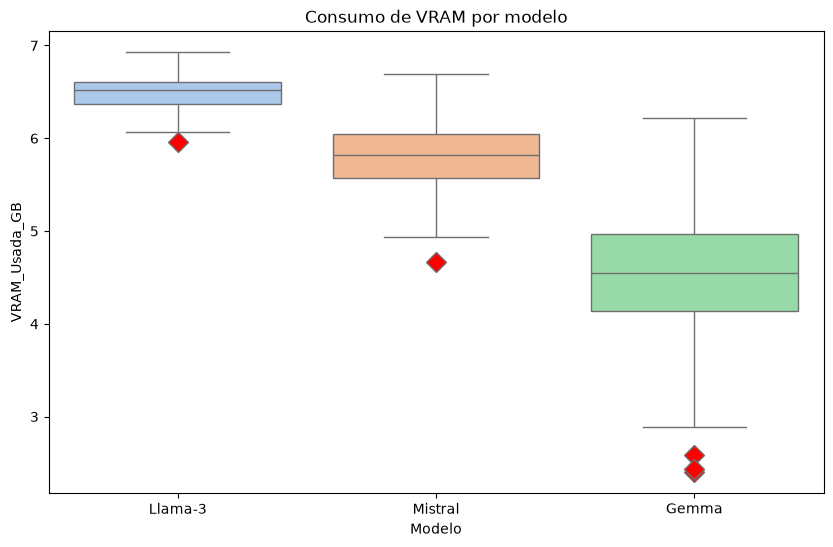

In [27]:
df_ia = pd.DataFrame(datos_ia)

plt.figure(figsize=(10,6))
plt.title('Consumo de VRAM por modelo')
sns.boxplot(data=df_ia, 
            x="Modelo", 
            y="VRAM_Usada_GB",
            hue="Modelo",
            palette="pastel",
            flierprops={'marker': 'D', "markerfacecolor":'red', "markersize": 10})
plt.show()






### Misión 2 (Violinplot): Estabilidad del Tiempo de Respuesta.

Usa un diagrama de violín para analizar el Tiempo_Inferencia_ms de cada modelo.

Dibuja las líneas de los cuartiles dentro del violín. (El gráfico revelará un comportamiento extraño en uno de los modelos).

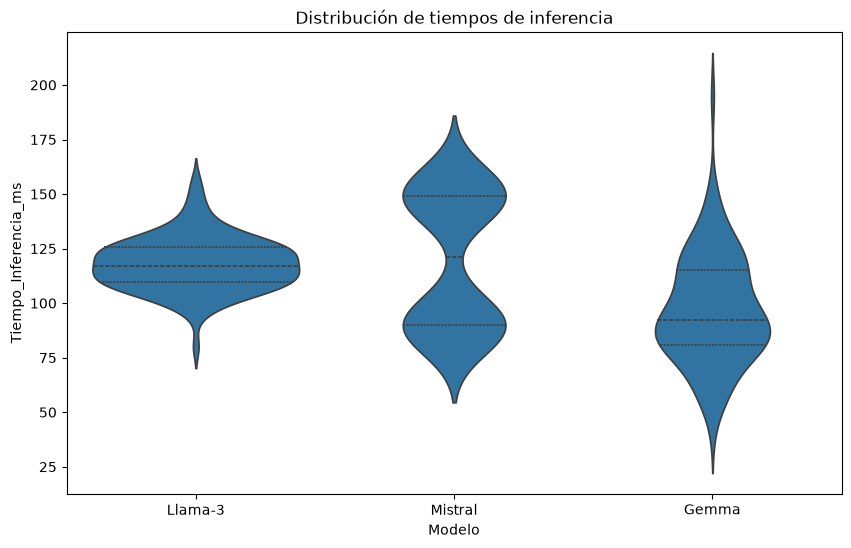

In [ ]:
plt.figure(figsize=(10,6))
plt.title('Distribución de tiempos de inferencia') 
sns.violinplot(data=df_ia, x="Modelo", y="Tiempo_Inferencia_ms",inner='quartile')
# inner 'box' (caja por defecto), 'quartile' (líneas de cuartiles), 'point' (puntos exactos), 'stick' (palitos)
plt.show()

### Misión 3 (Heatmap): Correlación de Métricas.

Calcula la matriz de correlación solo de las columnas numéricas.

Crea un mapa de calor que muestre los valores numéricos, usando un mapa de color que diferencie valores positivos y negativos, y aplica forma cuadrada a las celdas.

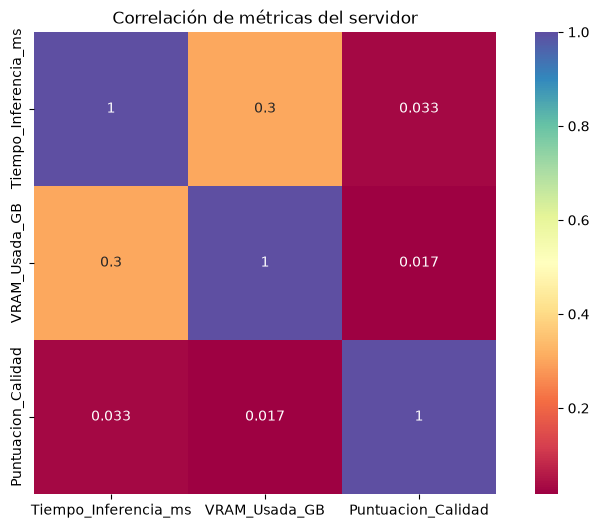

In [ ]:
matriz_correlacion = df_ia.corr(numeric_only=True) #coge solo las variables numéricas de un df

plt.figure(figsize=(10,6))
plt.title('Correlación de métricas del servidor')
sns.heatmap(data=matriz_correlacion, cmap='Spectral', annot=True, square=True)
#otros cmap: Spectral, vlag
#annot para que aparezca el coef de Pearson dentro de cada cuadrado
#square para que los cuadrados sean perfectos
plt.show()